# YOLOv8 experimental workflow
Horizontal publication figure with four stage groups and no ablation-control branch.
Edit `steps` to change labels, then run the code cell to export SVG, PDF and 600 dpi PNG.

Activation optimisation contains both activation choices and approximation strategies. Changing the mathematical function requires fine-tuning; approximations require numerical and detection-accuracy validation.
Sparse and fused execution are evaluated only for supported configurations.


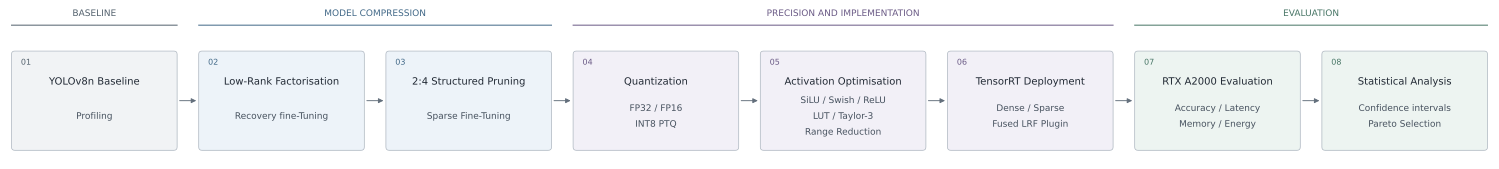

Exported flowchart.svg, flowchart.pdf and flowchart.png (600 dpi)


In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import SVG, display

# Publication figure: horizontal workflow, editable labels, vector exports.
steps = [
    ("YOLOv8n Baseline", ["Profiling"]),
    ("Low-Rank Factorisation", ["Recovery fine-Tuning"]),
    ("2:4 Structured Pruning", ["Sparse Fine-Tuning"]),
    ("Quantization", ["FP32 / FP16", "INT8 PTQ"]),
    ("Activation Optimisation", ["SiLU / Swish / ReLU", "LUT / Taylor-3", "Range Reduction"]),
    ("TensorRT Deployment", ["Dense / Sparse", "Fused LRF Plugin"]),
    ("RTX A2000 Evaluation", ["Accuracy / Latency", "Memory / Energy"]),
    ("Statistical Analysis", ["Confidence intervals", "Pareto Selection"]),
]
groups = [
    (0, 0, "BASELINE", "#f1f3f5", "#53616d"),
    (1, 2, "MODEL COMPRESSION", "#edf3f9", "#416887"),
    (3, 5, "PRECISION AND IMPLEMENTATION", "#f2f0f7", "#6a5a85"),
    (6, 7, "EVALUATION", "#edf4f1", "#477565"),
]
plt.rcParams.update({
    "font.family": "DejaVu Sans", "text.color": "#202833",
    "svg.fonttype": "none", "pdf.fonttype": 42,
})
width, gap, height = 2.30, 0.30, 1.38
margin, bottom = 0.16, 0.26
total = len(steps) * width + (len(steps)-1) * gap + 2*margin
fig, ax = plt.subplots(figsize=(total, 2.35), facecolor="white")
ax.set(xlim=(0, total), ylim=(0, 2.35), aspect="equal")
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
stage_colours = {}
for first, last, label, fill, accent in groups:
    start = margin + first*(width+gap)
    span = (last-first+1)*width + (last-first)*gap
    ax.plot([start, start+span], [2.00, 2.00], color=accent, linewidth=1.0)
    ax.text(start+span/2, 2.16, label, ha="center", va="center",
            fontsize=9, color=accent, fontweight="medium")
    for i in range(first, last+1):
        stage_colours[i] = (fill, accent)

for i, (title, details) in enumerate(steps):
    left = margin + i*(width+gap)
    fill, accent = stage_colours[i]
    ax.add_patch(FancyBboxPatch(
        (left, bottom), width, height,
        boxstyle="round,pad=0,rounding_size=0.045",
        facecolor=fill, edgecolor="#abb4be", linewidth=0.7,
    ))
    ax.text(left+0.13, bottom+height-0.16, f"{i+1:02d}",
            ha="left", va="center", fontsize=8, color=accent)
    ax.text(left+width/2, bottom+height-0.43, title,
            ha="center", va="center", fontsize=10, fontweight="medium")
    centre = bottom+0.47
    spacing = 0.22
    for j, line in enumerate(details):
        ax.text(left+width/2, centre+((len(details)-1)/2-j)*spacing,
                line, ha="center", va="center", fontsize=9, color="#46515e")
    if i < len(steps)-1:
        ax.add_patch(FancyArrowPatch(
            (left+width+0.035, bottom+height/2),
            (left+width+gap-0.035, bottom+height/2),
            arrowstyle="-|>", mutation_scale=10,
            color="#626e7b", linewidth=0.9, shrinkA=0, shrinkB=0,
        ))

# SVG and PDF retain sharp lines at publication scale.
output_dir = Path.cwd()
for extension in ("svg", "pdf", "png"):
    fig.savefig(output_dir / f"flowchart.{extension}", dpi=600,
                facecolor="white", metadata={"Creator": "YOLOv8 experimental workflow"})
plt.close(fig)
display(SVG(filename=str(output_dir / "flowchart.svg")))
print("Exported flowchart.svg, flowchart.pdf and flowchart.png (600 dpi)")

